# Idea
load model(s) and test them

# Imports

In [1]:
# import os
# os.nice(19)
# flake8: noqa: E402
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15
dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Models

In [4]:
MODEL_DIR = find_repo_root() / Path("Analysis/modeling/saved_models")

# load all models with joblib
model_types = ['MultiTaskLassoCV', 'lasso']
models = {}
scalers = {}

# example for loading one model and scaler
# model = joblib.load(MODEL_DIR / 'MultiTaskLassoCV_trend_model_1.pkl')
# scaler = joblib.load(MODEL_DIR / 'MultiTaskLassoCV_trend_scaler_1.pkl')

# regex to parse filenames
pattern = re.compile(
    r'(?P<model_type>.+?)_(?P<target>.+?)_(?P<kind>model|scaler)_(?P<number>\d+)\.pkl'
)

# --- sort files deterministically ---
pkl_files = sorted(
    MODEL_DIR.glob("*.pkl"),
    key=lambda p: (
        # extract number for numeric sorting
        int(pattern.match(p.name).group("number"))
        if pattern.match(p.name)
        else float("inf"),
        p.name,  # tie-breaker for absolute determinism
    ),
)

for pkl_file in pkl_files:
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    model_type = match.group("model_type")
    target = match.group("target")
    kind = match.group("kind")
    number = int(match.group("number"))

    if model_type not in model_types:
        continue

    # nested structure: models[model_type][target][number]
    if kind == "model":
        models.setdefault(model_type, {}).setdefault(target, {})[number] = (
            joblib.load(pkl_file)
        )

    elif kind == "scaler":
        scalers.setdefault(model_type, {}).setdefault(target, {})[number] = (
            joblib.load(pkl_file)
        )
# check if for each model there is a corresponding scaler
for model_type in models:
    for target in models[model_type]:
        for number in models[model_type][target]:
            assert number in scalers[model_type][target], f"Scaler missing for {model_type} {target} {number}"
print(f"✅ Successfully loaded models and scalers for model types: {list(models.keys())}")

✅ Successfully loaded models and scalers for model types: ['MultiTaskLassoCV', 'lasso']


Show all models

In [5]:
print("Loaded models:\n")

for model_type, targets in models.items():
    print(f"Model type: {model_type}")
    for target, model_nums in targets.items():
        nums = sorted(model_nums.keys())
        print(f"  Target: {target}")
        print(f"    Models: {nums}")
    print()

Loaded models:

Model type: MultiTaskLassoCV
  Target: trend
    Models: [1, 2, 3, 4]

Model type: lasso
  Target: orbital_decay
    Models: [1, 3, 4]
  Target: trend
    Models: [1, 2, 3, 4]



# Run Model

In [6]:
predictions = {}

for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for n, model in model_nums.items():

            scaler = scalers[model_type][target][n]

            # scale X_test
            X_test_scaled = pd.DataFrame(
                scaler.transform(X_test),
                index=X_test.index,
                columns=X_test.columns
            )

            # predict
            y_test_pred = pd.DataFrame(
                model.predict(X_test_scaled),
                index=X_test.index,
                columns=y_test.columns
            )

            # store
            predictions.setdefault(model_type, {}) \
                       .setdefault(target, {})[n] = y_test_pred

# Results

## Check Coefficients

In [7]:
coef_df = pd.DataFrame(index=X_test.columns)

for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for number, model in model_nums.items():

            # skip models without coefficients
            if not hasattr(model, "coef_"):
                continue

            coef = model.coef_[1, :] if model.coef_.ndim == 2 else model.coef_

            col_name = f"coeff_{model_type}_{target}_{number}"

            coef_df[col_name] = coef

# reset index to have feature as a column (optional)
coef_df = coef_df.reset_index().rename(columns={"index": "feature"})
unique_models = []
alphas = []

# create new dataframe with sorted names
sorted_coef_df = coef_df.copy()
for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for number, model in model_nums.items():

            # skip models without coefficients
            if not hasattr(model, "coef_"):
                continue

            if hasattr(model, "alpha_"):
                alpha = model.alpha_
                alphas.append(alpha)
            elif hasattr(model, "alpha"):
                alpha = model.alpha
                alphas.append(alpha)
            else:
                alpha = None
                alphas.append(alpha)

            col_name = f"coeff_{model_type}_{target}_{number}"
            unique_models.append(f"{model_type}_{target}_{number}")
            temp = coef_df.sort_values(by=col_name, key=abs, ascending=False)

            sorted_coef_df[col_name] = temp['feature'].values
# remove 'feature' column for sorting
features = sorted_coef_df.pop('feature')

# save to csv
coef_df.to_csv(MODEL_DIR / "model_coefficients_comparison.csv", index=False)
sorted_coef_df.to_csv(MODEL_DIR / "model_coefficients_sorted_comparison.csv", index=False)

# convert lag to time in hours
stepsize = 5 / 60 # in hours
coef_df[["feature", "lag"]] = (
    coef_df["feature"]
    .str.extract(r"^(?P<feature_name>.+?)_lag_(?P<lag>\d+)$")
)
coef_df['lag_time'] = coef_df['lag'].astype(int) * stepsize


Plot

In [8]:
def parse_model_name(model_name: str):
    """
    Parse model name of the form: model_type_target_No
    """
    model_type, target, No = model_name.rsplit("_", 2)
    return model_type, target, int(No)

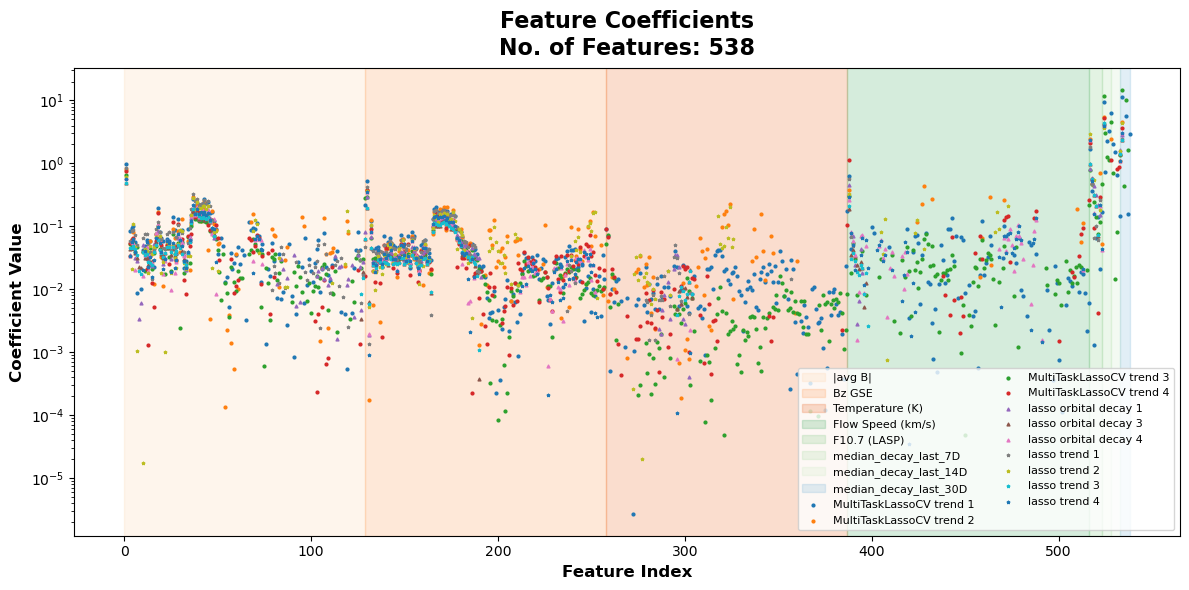

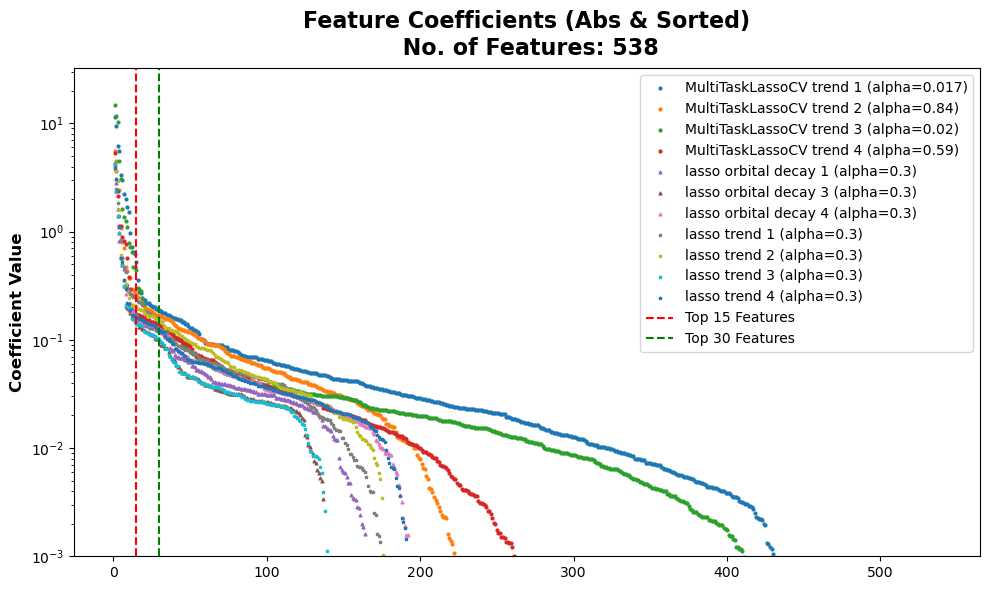

In [9]:
lag_config_trend = {
    "|avg B|": 129,
    "Bz GSE": 129,
    "Temperature (K)": 129,
    "Flow Speed (km/s)": 129,
    "F10.7 (LASP)": 7,
    "median_decay_last_7D": 5,
    "median_decay_last_14D": 5,
    "median_decay_last_30D": 5,
}

colors = [
    "#fdd0a2", "#fd8d3c", "#e6550d",
    "#31a354", "#74c476", "#a1d99b", "#c7e9c0", "#6baed6"
]

group_positions = {}
start = 0
for i, (feature, length) in enumerate(lag_config_trend.items()):
    end = start + length
    group_positions[feature] = (start, end)
    start = end


fig, ax = plt.subplots(figsize=(12, 6))

# shade backgrounds
for i, (feature, (start, end)) in enumerate(group_positions.items()):
    ax.axvspan(start, end, color=colors[i % len(colors)], alpha=0.2, label=feature)

# plot coefficients
for model in unique_models:
    label_name = model.replace('_', ' ')
    col_name = f"coeff_{model}"

    model_type, target, number = parse_model_name(model)
    # change marker shape based on model type
    if model_type == 'MultiTaskLassoCV':
        marker = 'o'
    elif model_type == 'lasso':
        marker = '*'
    else:
        marker = '^'

    ax.scatter(
        range(1, len(coef_df)+1),
        abs(coef_df[col_name]),
        s=4,
        marker=marker,
        label=label_name
    )

ax.set_ylabel("Coefficient Value")
ax.set_xlabel("Feature Index")
ax.set_title(f"Feature Coefficients\nNo. of Features: {len(coef_df)}")
ax.set_yscale("log")

# handle legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="lower right", fontsize=8, ncol = 2)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(unique_models):
    label_name = model.replace('_', ' ')
    col_name = f"coeff_{model}"
    coefs = abs(coef_df[col_name])
    alpha = alphas[i]
    if alpha is not None:
        label_name += f" (alpha={alpha:.2})"
    # sort by size
    coefs_sorted = coefs.sort_values(ascending=False).reset_index(drop=True)

    model_type, target, number = parse_model_name(model)
    # change marker shape based on model type
    if model_type == 'MultiTaskLassoCV':
        marker = 'o'
    elif model_type == 'lasso':
        marker = '*'
    else:
        marker = '^'

    ax.scatter(range(1,len(coef_df)+1), coefs_sorted, s = 4, marker=marker, label=label_name)
ax.axvline(x=15, color='red', linestyle='--', label='Top 15 Features')
ax.axvline(x=30, color='green', linestyle='--', label='Top 30 Features')
ax.set_ylabel('Coefficient Value')
ax.set_title(f'Feature Coefficients (Abs & Sorted)\n No. of Features: {len(coef_df)}')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


Feature: |avg B|
MultiTaskLassoCV trend 1 (83.7%) - Coefs kept: 108 of 129
MultiTaskLassoCV trend 2 (48.8%) - Coefs kept: 63 of 129
MultiTaskLassoCV trend 3 (82.9%) - Coefs kept: 107 of 129
MultiTaskLassoCV trend 4 (50.4%) - Coefs kept: 65 of 129
lasso orbital decay 1 (56.6%) - Coefs kept: 73 of 129
lasso orbital decay 3 (38.8%) - Coefs kept: 50 of 129
lasso orbital decay 4 (39.5%) - Coefs kept: 51 of 129
lasso trend 1 (58.1%) - Coefs kept: 75 of 129
lasso trend 2 (42.6%) - Coefs kept: 55 of 129
lasso trend 3 (38.8%) - Coefs kept: 50 of 129
lasso trend 4 (39.5%) - Coefs kept: 51 of 129

Feature: Bz GSE
MultiTaskLassoCV trend 1 (96.1%) - Coefs kept: 124 of 129
MultiTaskLassoCV trend 2 (74.4%) - Coefs kept: 96 of 129
MultiTaskLassoCV trend 3 (95.3%) - Coefs kept: 123 of 129
MultiTaskLassoCV trend 4 (93.0%) - Coefs kept: 120 of 129
lasso orbital decay 1 (47.3%) - Coefs kept: 61 of 129
lasso orbital decay 3 (46.5%) - Coefs kept: 60 of 129
lasso orbital decay 4 (71.3%) - Coefs kept: 92 of 

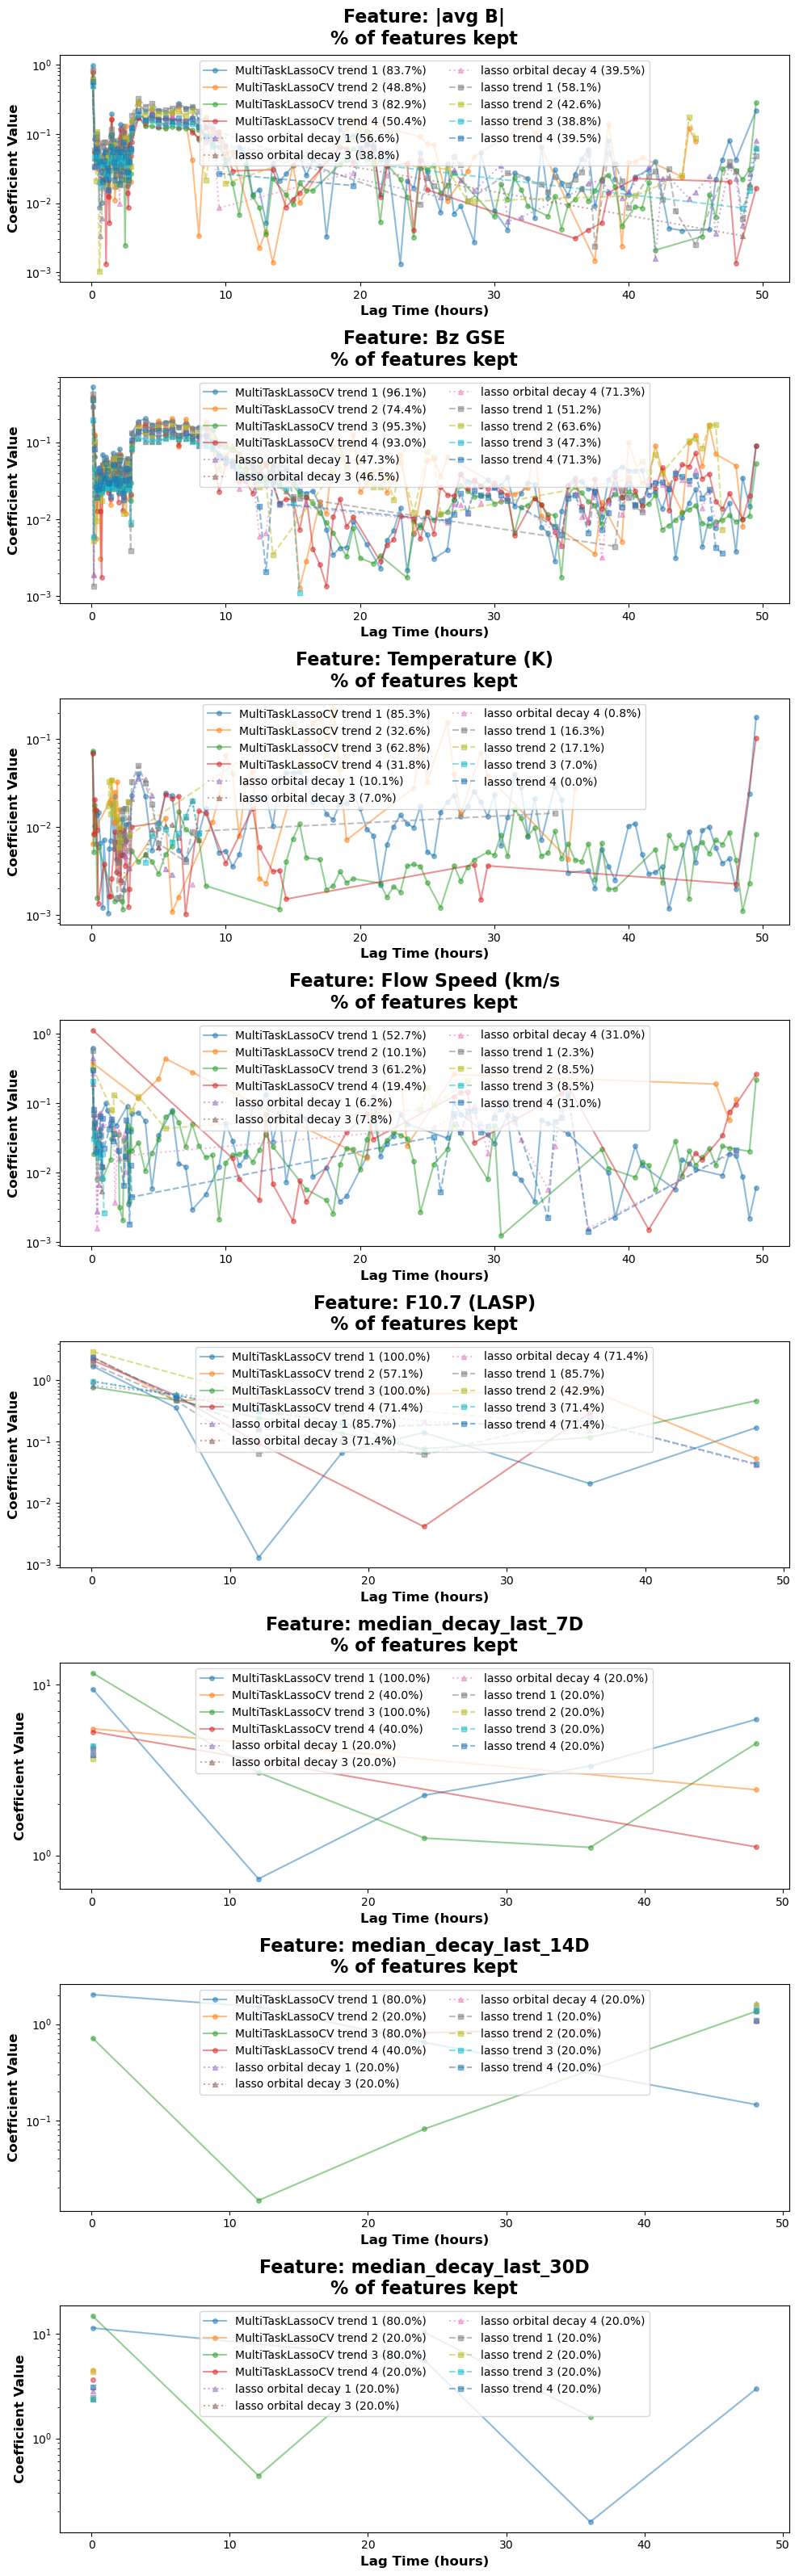

In [10]:
# unique features
unique_features = coef_df['feature'].unique()

fig, axs = plt.subplots(len(unique_features), 1, figsize=(10, 4 * len(unique_features)))
for i, feature in enumerate(unique_features):
    ax = axs[i] if len(unique_features) > 1 else axs
    feature_coefs = coef_df[coef_df['feature'] == feature]
    print(f"\nFeature: {feature}")
    for model in unique_models:
        label_name = model.replace('_', ' ')
        col_name = f"coeff_{model}"
        coefs = feature_coefs[['lag_time', col_name]]
        total_length = len(coefs)
        # only include coef values grater than 1e-3
        coefs = coefs[coefs[col_name].abs() > 1e-3].sort_values(by='lag_time')
        # percentage of coefs kept
        percentage_kept = len(coefs) / total_length * 100
        label_name += f" ({percentage_kept:.1f}%)"
        print(f"{label_name} - Coefs kept: {len(coefs)} of {total_length}")
        
        model_type, target, number = parse_model_name(model)
        # change marker shape based on model type
        if model_type == 'MultiTaskLassoCV':
            linestyle = '-'
            marker = 'o'
        elif model_type == 'lasso':
            linestyle = '--'
            marker = 's'
        else:
            linestyle = ':'
            marker = '^'

        ax.plot(
            coefs['lag_time'],
            abs(coefs[col_name]),
            marker=marker,
            ls=linestyle,
            ms=4,
            alpha = 0.5,
            label=label_name
        )
    
    ax.set_title(f'Feature: {feature}\n% of features kept')
    ax.set_xlabel('Lag Time (hours)')
    ax.set_ylabel('Coefficient Value')
    ax.set_yscale('log')
    ax.legend(loc='upper center', ncol = 2)
# plot legend outside of plots
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=3)
# plt.xlabel('Lag Time (hours)')
plt.tight_layout()
plt.show()


Feature: |avg B|
MultiTaskLassoCV trend 1 (83.7%) - Coefs kept: 108 of 129
MultiTaskLassoCV trend 2 (48.8%) - Coefs kept: 63 of 129
MultiTaskLassoCV trend 3 (82.9%) - Coefs kept: 107 of 129
MultiTaskLassoCV trend 4 (50.4%) - Coefs kept: 65 of 129
lasso orbital decay 1 (56.6%) - Coefs kept: 73 of 129
lasso orbital decay 3 (38.8%) - Coefs kept: 50 of 129
lasso orbital decay 4 (39.5%) - Coefs kept: 51 of 129
lasso trend 1 (58.1%) - Coefs kept: 75 of 129
lasso trend 2 (42.6%) - Coefs kept: 55 of 129
lasso trend 3 (38.8%) - Coefs kept: 50 of 129
lasso trend 4 (39.5%) - Coefs kept: 51 of 129

Feature: Bz GSE
MultiTaskLassoCV trend 1 (96.1%) - Coefs kept: 124 of 129
MultiTaskLassoCV trend 2 (74.4%) - Coefs kept: 96 of 129
MultiTaskLassoCV trend 3 (95.3%) - Coefs kept: 123 of 129
MultiTaskLassoCV trend 4 (93.0%) - Coefs kept: 120 of 129
lasso orbital decay 1 (47.3%) - Coefs kept: 61 of 129
lasso orbital decay 3 (46.5%) - Coefs kept: 60 of 129
lasso orbital decay 4 (71.3%) - Coefs kept: 92 of 

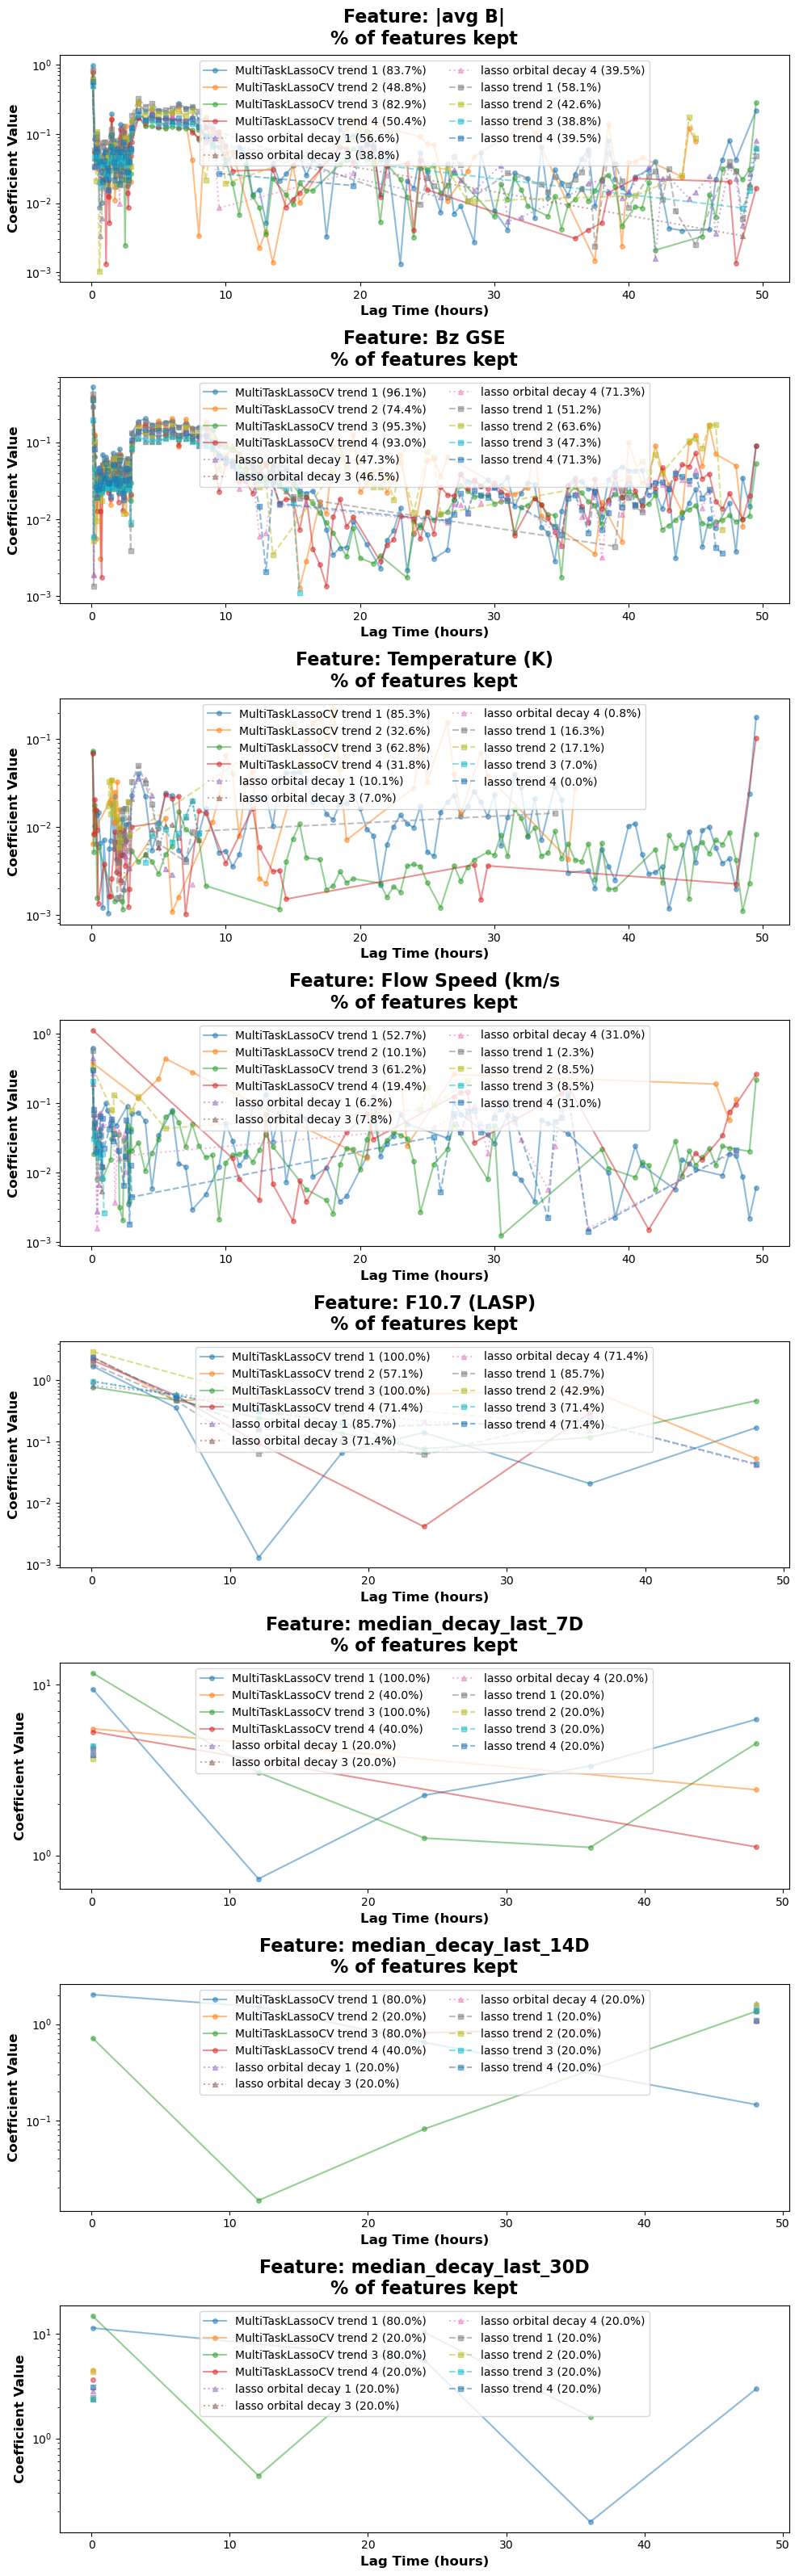

In [11]:
# unique features
unique_features = coef_df['feature'].unique()

fig, axs = plt.subplots(len(unique_features), 1, figsize=(10, 4 * len(unique_features)))
for i, feature in enumerate(unique_features):
    ax = axs[i] if len(unique_features) > 1 else axs
    feature_coefs = coef_df[coef_df['feature'] == feature]
    print(f"\nFeature: {feature}")
    for model in unique_models:
        label_name = model.replace('_', ' ')
        col_name = f"coeff_{model}"
        coefs = feature_coefs[['lag_time', col_name]]
        total_length = len(coefs)
        # only include coef values grater than 1e-3
        coefs = coefs[coefs[col_name].abs() > 1e-3].sort_values(by='lag_time')
        # percentage of coefs kept
        percentage_kept = len(coefs) / total_length * 100
        label_name += f" ({percentage_kept:.1f}%)"
        print(f"{label_name} - Coefs kept: {len(coefs)} of {total_length}")
        
        model_type, target, number = parse_model_name(model)
        # change marker shape based on model type
        if model_type == 'MultiTaskLassoCV':
            linestyle = '-'
            marker = 'o'
        elif model_type == 'lasso':
            linestyle = '--'
            marker = 's'
        else:
            linestyle = ':'
            marker = '^'

        ax.plot(
            coefs['lag_time'],
            abs(coefs[col_name]),
            marker=marker,
            ls=linestyle,
            ms=4,
            alpha = 0.5,
            label=label_name
        )
    
    ax.set_title(f'Feature: {feature}\n% of features kept')
    ax.set_xlabel('Lag Time (hours)')
    ax.set_ylabel('Coefficient Value')
    ax.set_yscale('log')
    ax.legend(loc='upper center', ncol = 2)
# plot legend outside of plots
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=3)
# plt.xlabel('Lag Time (hours)')
plt.tight_layout()
plt.show()

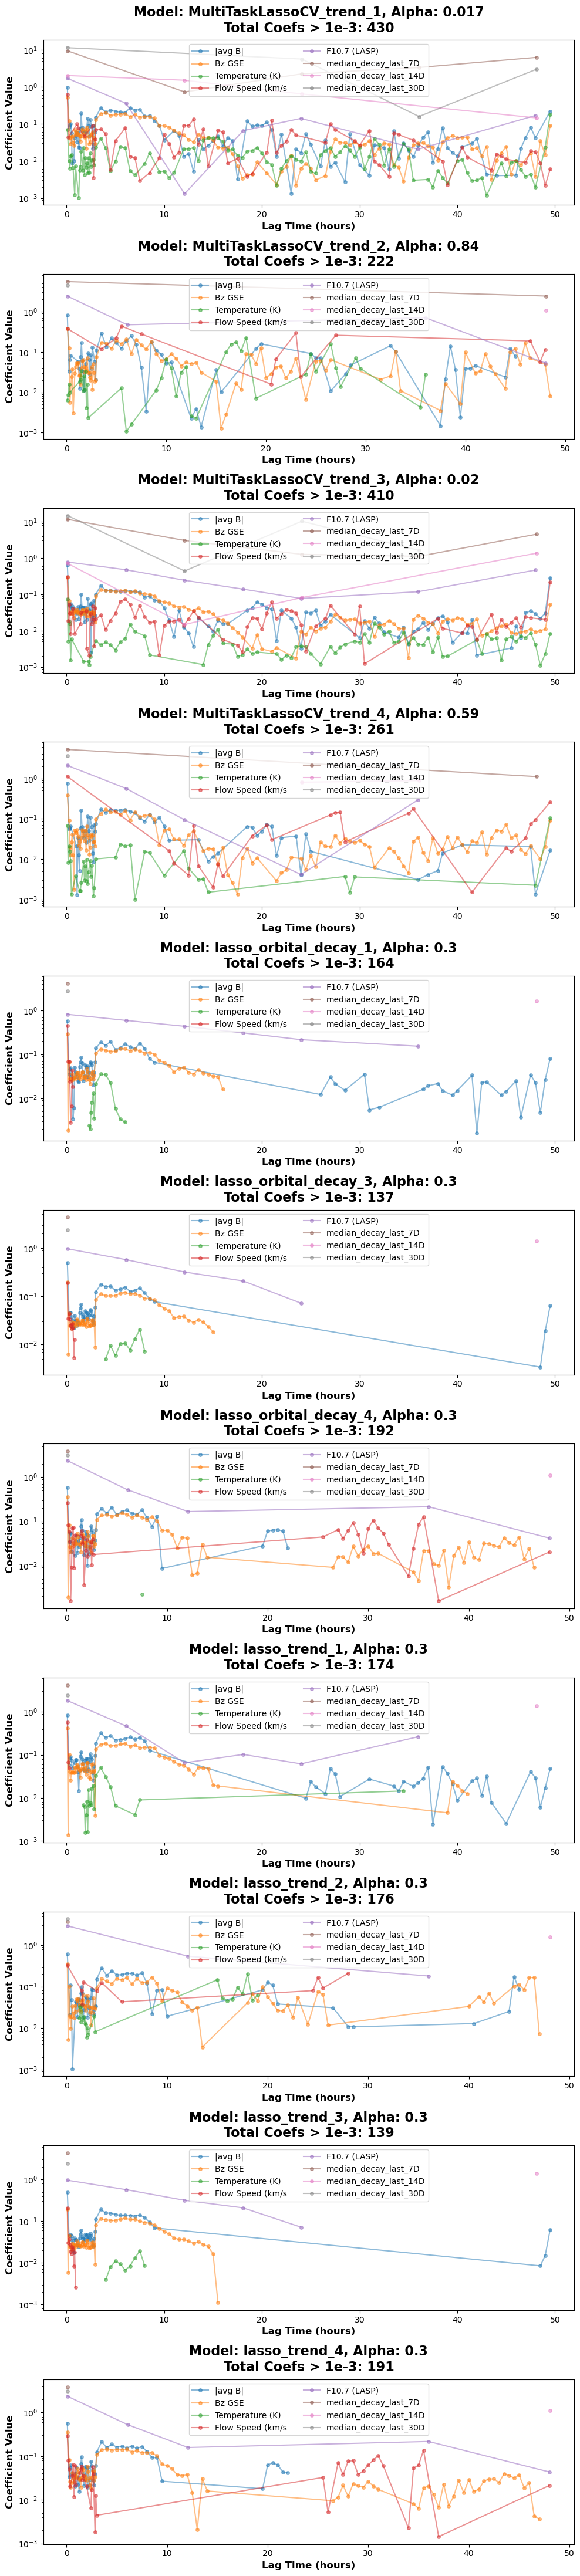

In [12]:
fig, axs = plt.subplots(len(unique_models), 1, figsize=(10, 4 * len(unique_models)))
for i, model in enumerate(unique_models):
    ax = axs[i] if len(unique_models) > 1 else axs
    col_name = f"coeff_{model}"
    for feature in unique_features:
        feature_coefs = coef_df[coef_df['feature'] == feature]
        label_name = feature
        
        coefs = feature_coefs[['lag_time', col_name]]
        # only include coef values grater than 1e-3
        coefs = coefs[coefs[col_name].abs() > 1e-3].sort_values(by='lag_time')
        ax.plot(
            coefs['lag_time'],
            abs(coefs[col_name]),
            marker='o',
            ms=4,
            alpha = 0.5,
            label=label_name
        )
    # total coefs bigger than 1e-3
    total_coefs = coef_df[coef_df[col_name].abs() > 1e-3][col_name].abs().nunique()
    ax.set_title(f'Model: {model}, Alpha: {alphas[i]:.2}\nTotal Coefs > 1e-3: {total_coefs}' )
    ax.set_xlabel('Lag Time (hours)')
    ax.set_ylabel('Coefficient Value')
    ax.set_yscale('log')
    ax.legend(loc='upper center', ncol = 2)
# plot legend outside of plots
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=3)
# plt.xlabel('Lag Time (hours)')
plt.tight_layout()
plt.show()

## Check Test Error

KeyError: 'lasso_orbital'

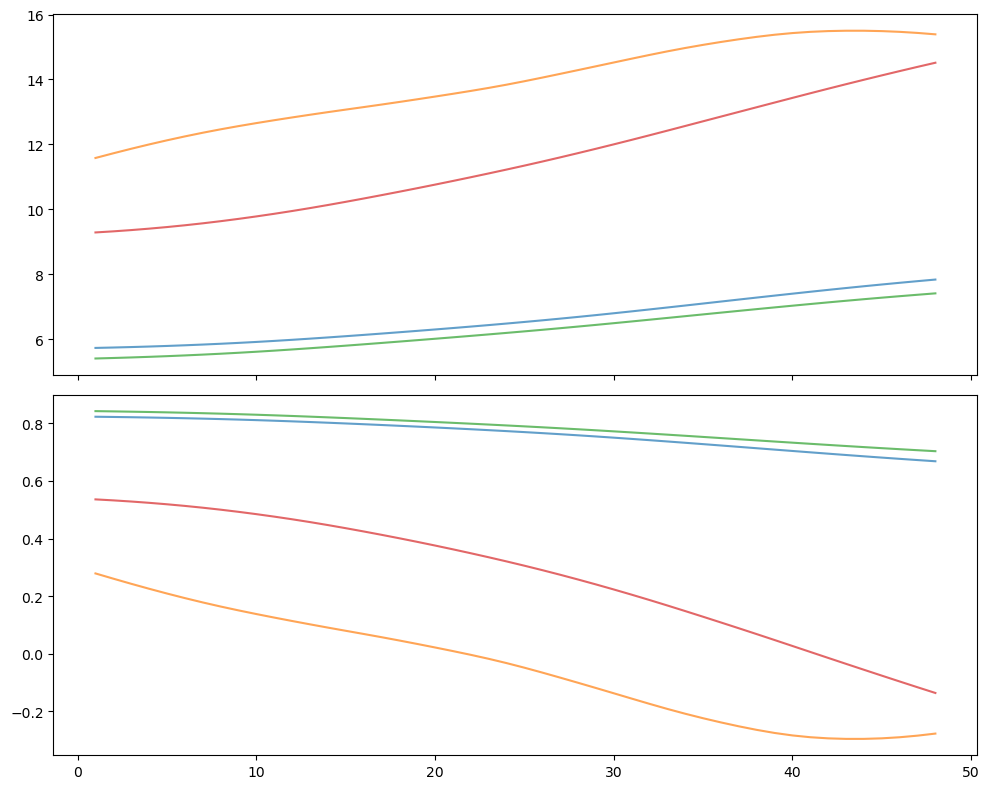

In [13]:
xtest = [int(col.split('_')[-1]) for col in y_test.iloc[0].index]

fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for model in unique_models:
    model_type, target, number = parse_model_name(model)
    y_test_pred = predictions[model_type][target][number]
    
    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    test_rmse_list = []
    test_r2_list = []

    for i in range(len(y_test.columns)):
        test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
        test_r2_list.append(r2_score(y_test.iloc[:, i], y_test_pred.iloc[:, i]))

    model_label = model.replace('_', ' ')
    # select linestyle based on model type
    if model_type == 'MultiTaskLassoCV':
        linestyle = '-'
    elif model_type == 'lasso':
        linestyle = '--'
    else:
        linestyle = ':'
    ax[0].plot(xtest,test_rmse_list, label=f'{model_label}, Test RMSE: {test_rmse:.3}', linestyle=linestyle, alpha=0.7)
    ax[1].plot(xtest, test_r2_list, label=f'{model_label}, Test R2: {test_r2:.3}', linestyle=linestyle, alpha=0.7)
ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[0].grid(True)

ax[1].set_ylabel('R2 Score')
ax[1].set_xlabel('Forecast Step (20s intervals)')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

## Plot single forecasts

In [ ]:
def plot_forecast_for_event(time, target):
    idx = y_test.index.get_loc(time)
    time_idx = y_test.index[idx]

    # Extract sample
    sample_test = X_test.iloc[idx]
    sample_test_F = sample_test.filter(like='F10.7')
    sample_test_B = sample_test.filter(like='|avg B|')
    # sample_test_y = y_test.iloc[idx]

    # Compute lag times
    lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
    lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]
    # lag_times_y = [int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_y.index]

    sample_test_F.index = lag_times_F
    sample_test_B.index = lag_times_B

    # Define time window for decay plotting
    time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
    print(repr(target))
    true_decay = GFOC_data.loc[time_window[0]:time_window[1], target]

    bz_window = GFOC_data.loc[time_window[0]:time_window[1], '|avg B|']

    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)
    ax = ax.flatten()

    # Plot lagged features
    ax[0].scatter(sample_test_F.index, sample_test_F.values, color='blue')
    ax2 = ax[0].twinx()
    ax2.scatter(sample_test_B.index, sample_test_B.values, color='orange', alpha=0.7)

    ax[0].set_title(f'Input lags for F10.7 and |avg B| for event time {time_idx}')
    ax[0].set_xlabel('Lagged Features')
    ax[0].set_ylabel('F10.7 Value', color='blue')
    ax2.set_ylabel('|avg B| Value', color='orange')
    ax[0].grid(True)

    xticks = ax[0].get_xticks()
    ax[0].set_xticklabels([f'{int(t/60)}h' for t in xticks])

    # Plot true decay trend
    ax[1].plot(true_decay.index, true_decay.values, label=f'True {target}', color='black')
    # Plot predicted decay trends for all models
    for model in unique_models:
        model_type, target, number = parse_model_name(model)
        y_test_pred = predictions[model_type][target][number]
        pred_trend = y_test_pred.iloc[idx]
        pred_times = [time_idx + pd.Timedelta(minutes=m * (i + 1)) for i in range(len(pred_trend))]
        if model_type == 'MultiTaskLassoCV':
            marker = '.'
        elif model_type == 'lasso':
            marker = '*'
        else:
            marker = '^'
        ax[1].plot(pred_times, pred_trend.values, marker=marker, linestyle='None', alpha = 0.5, label=f'Pred for {model}')

    ax[1].set_title(f'Predicted {target} vs. True {target}')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Decay Rate (m/day)')
    ax[1].legend()
    ax[1].grid(True)

    # Overlay |avg B| on second plot
    ax2 = ax[1].twinx()
    ax2.scatter(bz_window.index, bz_window.values, color='blue', alpha=0.8, s=1)
    ax2.set_ylabel('|avg B|', color='blue')

    # Mark forecast horizon start time
    ax[1].axvline(time_idx, color='gray', linestyle='--', label='Forecast Horizon Start Time')

    plt.tight_layout()
    plt.show()

'trend'


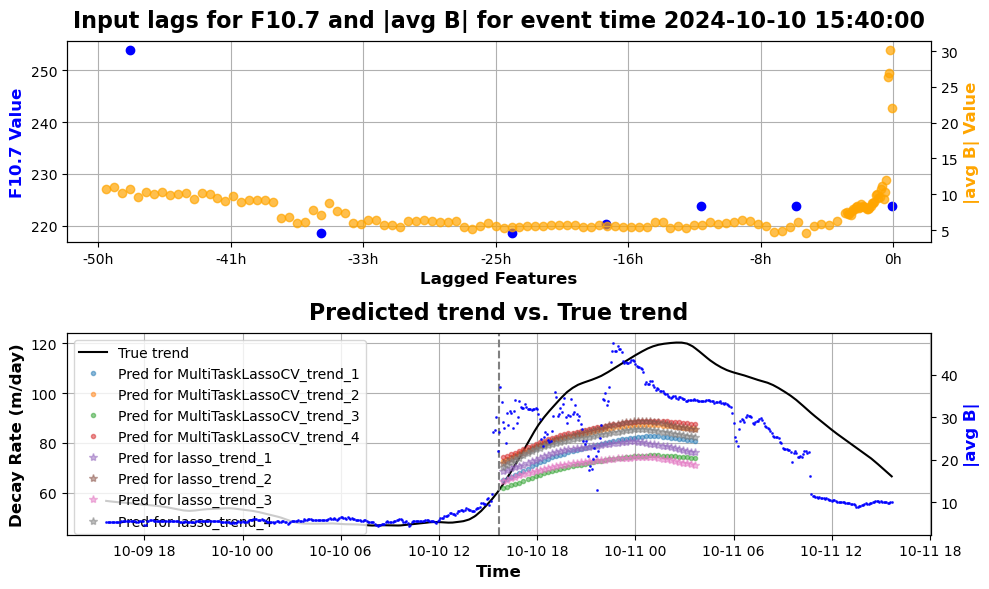

In [ ]:
event_time = '2024-10-10 15:40:00'
plot_forecast_for_event(event_time, target)

# Analysis 1

training on all data vs on events = on all data doesn’t bring much info extra – can compare Model 1 model 3

## Result
If we look at the test error, we see that the model does not get much better if we use all datapoints compared to when we only used 'events'. Thus we can save a lot of computation time if we only use the latter.

In [ ]:
def plot_scores(model_types, targets, numbers):
    fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for model_type in model_types:
        for target in targets:
            for number in numbers:
                y_test_pred = predictions[model_type][target][number]
            
                test_rmse = root_mean_squared_error(y_test, y_test_pred)
                test_r2 = r2_score(y_test, y_test_pred)

                test_rmse_list = []
                test_r2_list = []

                for i in range(len(y_test.columns)):
                    test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
                    test_r2_list.append(r2_score(y_test.iloc[:, i], y_test_pred.iloc[:, i]))

                model_label = f"{model_type} {target} {number}"
                # select linestyle based on model type
                if model_type == 'MultiTaskLassoCV':
                    linestyle = '-'
                elif model_type == 'lasso':
                    linestyle = '--'
                else:
                    linestyle = ':'
                ax[0].plot(xtest,test_rmse_list, label=f'{model_label}, Test RMSE: {test_rmse:.3}', linestyle=linestyle, alpha=0.7)
                ax[1].plot(xtest, test_r2_list, label=f'{model_label}, Test R2: {test_r2:.3}', linestyle=linestyle, alpha=0.7)
    ax[0].set_ylabel('RMSE')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_ylabel('R2 Score')
    ax[1].set_xlabel('Forecast Step (20s intervals)')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()

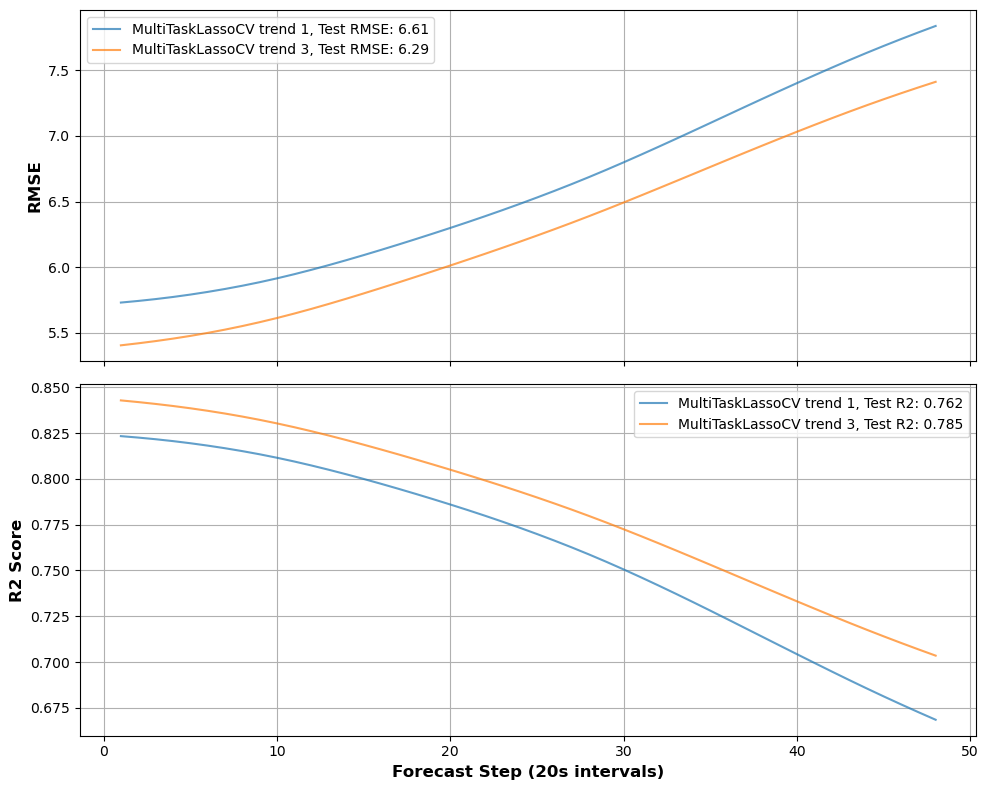

In [ ]:
model_types = ['MultiTaskLassoCV']
targets = ['trend']
numbers = [1,3]

plot_scores(model_types, targets, numbers)

# Analysis 2




Feature: |avg B|
MultiTaskLassoCV trend 1 (83.7%) - Coefs kept: 108 of 129
lasso trend 1 (58.1%) - Coefs kept: 75 of 129

Feature: Bz GSE
MultiTaskLassoCV trend 1 (96.1%) - Coefs kept: 124 of 129
lasso trend 1 (51.2%) - Coefs kept: 66 of 129

Feature: Temperature (K)
MultiTaskLassoCV trend 1 (85.3%) - Coefs kept: 110 of 129
lasso trend 1 (16.3%) - Coefs kept: 21 of 129

Feature: Flow Speed (km/s
MultiTaskLassoCV trend 1 (52.7%) - Coefs kept: 68 of 129
lasso trend 1 (2.3%) - Coefs kept: 3 of 129

Feature: F10.7 (LASP)
MultiTaskLassoCV trend 1 (100.0%) - Coefs kept: 7 of 7
lasso trend 1 (85.7%) - Coefs kept: 6 of 7

Feature: median_decay_last_7D
MultiTaskLassoCV trend 1 (100.0%) - Coefs kept: 5 of 5
lasso trend 1 (20.0%) - Coefs kept: 1 of 5

Feature: median_decay_last_14D
MultiTaskLassoCV trend 1 (80.0%) - Coefs kept: 4 of 5
lasso trend 1 (20.0%) - Coefs kept: 1 of 5

Feature: median_decay_last_30D
MultiTaskLassoCV trend 1 (80.0%) - Coefs kept: 4 of 5
lasso trend 1 (20.0%) - Coefs kept

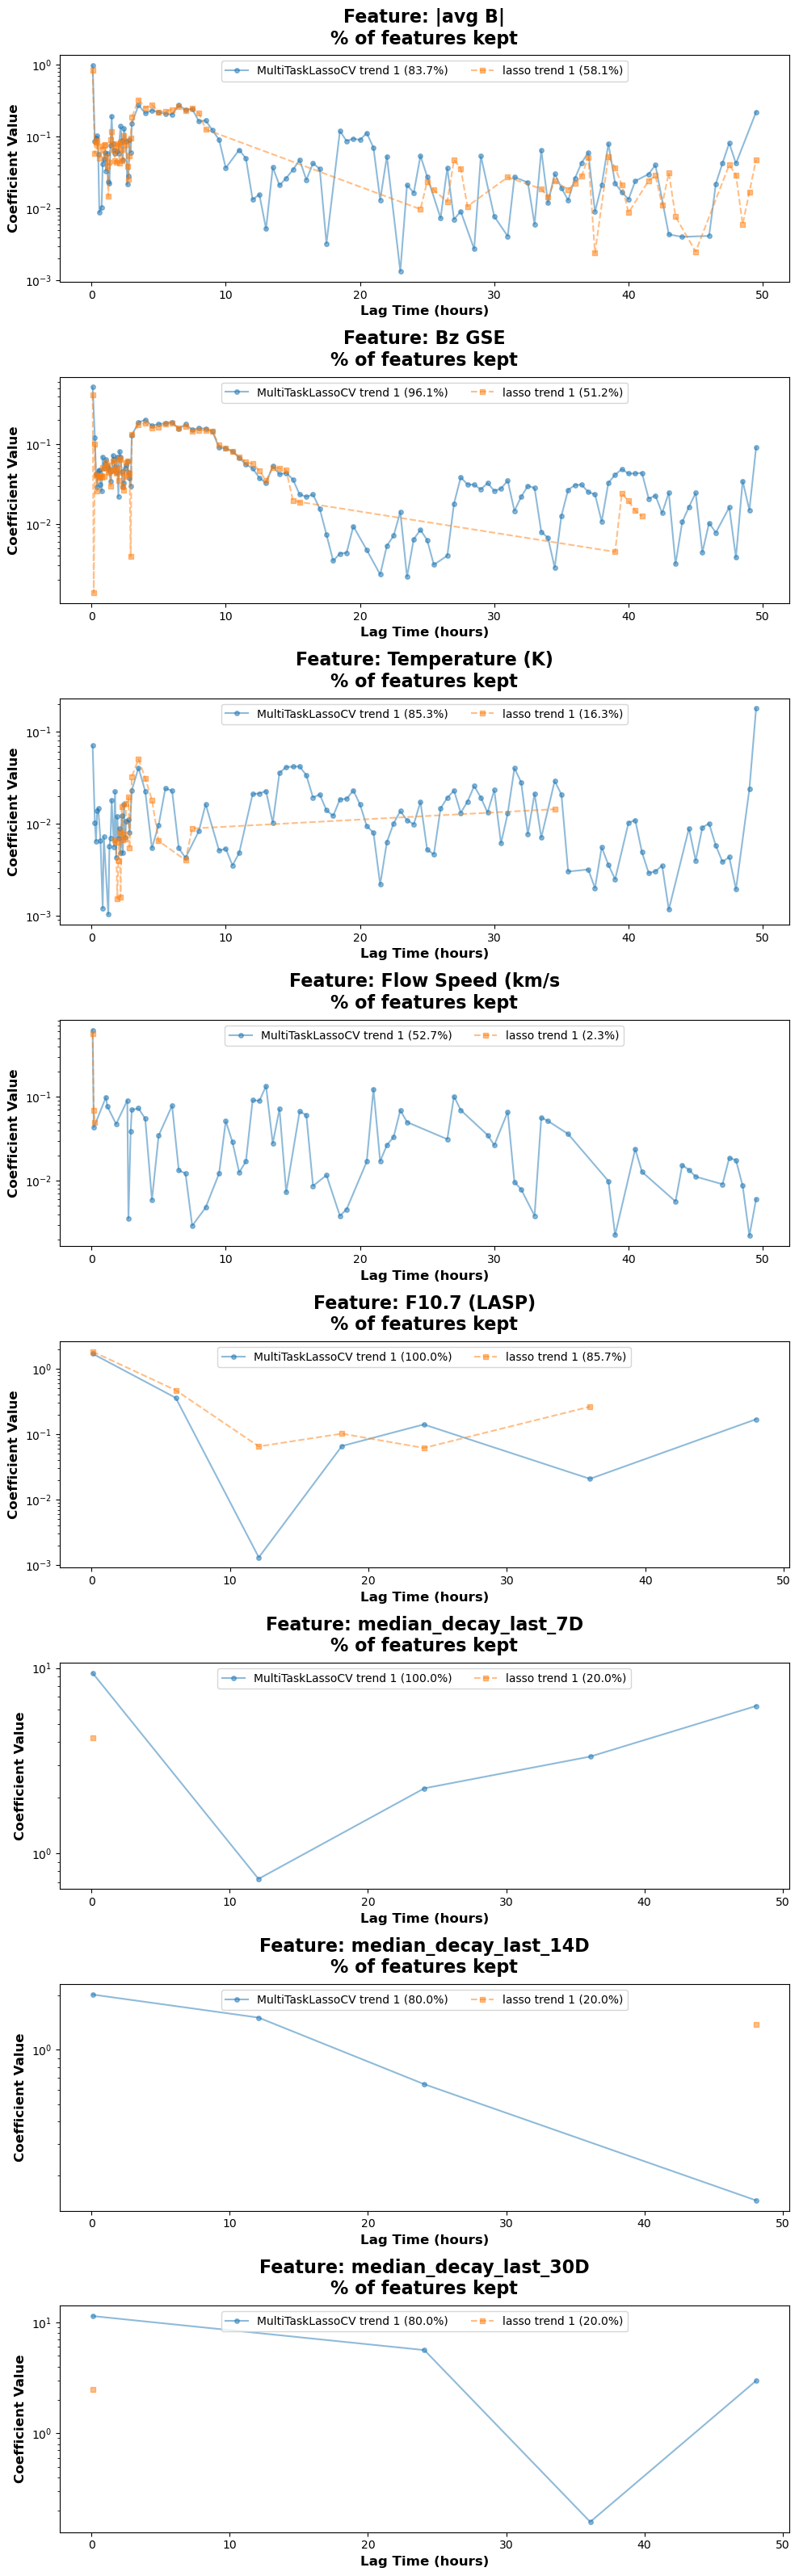

In [ ]:
# unique features
unique_features = coef_df['feature'].unique()
unique_models = [model for model in unique_models if '1' in model]

fig, axs = plt.subplots(len(unique_features), 1, figsize=(10, 4 * len(unique_features)))
for i, feature in enumerate(unique_features):
    ax = axs[i] if len(unique_features) > 1 else axs
    feature_coefs = coef_df[coef_df['feature'] == feature]
    print(f"\nFeature: {feature}")
    for model in unique_models:
        label_name = model.replace('_', ' ')
        col_name = f"coeff_{model}"
        coefs = feature_coefs[['lag_time', col_name]]
        total_length = len(coefs)
        # only include coef values grater than 1e-3
        coefs = coefs[coefs[col_name].abs() > 1e-3].sort_values(by='lag_time')
        # percentage of coefs kept
        percentage_kept = len(coefs) / total_length * 100
        label_name += f" ({percentage_kept:.1f}%)"
        print(f"{label_name} - Coefs kept: {len(coefs)} of {total_length}")
        
        model_type, target, number = parse_model_name(model)
        # change marker shape based on model type
        if model_type == 'MultiTaskLassoCV':
            linestyle = '-'
            marker = 'o'
        elif model_type == 'lasso':
            linestyle = '--'
            marker = 's'
        else:
            linestyle = ':'
            marker = '^'

        ax.plot(
            coefs['lag_time'],
            abs(coefs[col_name]),
            marker=marker,
            ls=linestyle,
            ms=4,
            alpha = 0.5,
            label=label_name
        )
    
    ax.set_title(f'Feature: {feature}\n% of features kept')
    ax.set_xlabel('Lag Time (hours)')
    ax.set_ylabel('Coefficient Value')
    ax.set_yscale('log')
    ax.legend(loc='upper center', ncol = 2)
# plot legend outside of plots
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=3)
# plt.xlabel('Lag Time (hours)')
plt.tight_layout()
plt.show()